In [4]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 처음 실행하는 경우 아래 두 줄의 주석을 풀어 설치하세요.
%pip install missingno plotly -q
%pip install --upgrade nbformat 
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import plotly.express as px
import plotly.io as pio

warnings.filterwarnings("ignore")
np.random.seed(42)

# 한글 폰트 (운영체제별 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# Plotly는 환경에 따라 기본 렌더러가 다릅니다.
# 노트북에서 인터랙티브로 보이도록 명시적으로 지정합니다.
try:
    pio.renderers.default = "notebook"
except Exception:
    pass

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("pandas    :", pd.__version__)
print("seaborn   :", sns.__version__)
print("missingno :", msno.__version__ if hasattr(msno, "__version__") else "(installed)")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
준비 완료! 라이브러리 버전을 확인합니다.
pandas    : 3.0.3
seaborn   : 0.13.2
missingno : 0.5.2


In [5]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 정제 전(raw)과 정제 후(clean) 두 버전
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객
n_customers = 500
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
})
# 일부러 심은 오염
customers.loc[5, "age"] = 999
customers.loc[10, "age"] = -3
customers.loc[[20, 21, 22, 23], "gender"] = np.nan
customers.loc[30, "region"] = " 서울 "

# 2) 상품
categories = ["패션", "뷰티", "식품", "가전", "도서"]
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, 41)],
    "category": np.random.choice(categories, 40),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], 40),
})

# 3) 주문 — 정제 전 버전
n_orders = 3000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders_raw = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "quantity": quantity.astype(float),
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05]),
})

# 의도적 오염: amount의 일부는 결측(특히 web 채널에서 더 자주 결측 — MAR 패턴)
web_mask = orders_raw["channel"] == "web"
web_idx = orders_raw[web_mask].sample(150, random_state=1).index
other_idx = orders_raw[~web_mask].sample(40, random_state=1).index
orders_raw.loc[web_idx, "amount"] = np.nan
orders_raw.loc[other_idx, "amount"] = np.nan

# quantity 이상치
orders_raw.loc[7, "quantity"] = 100
orders_raw.loc[123, "quantity"] = 80

# amount 이상치(VIP 한 명의 대량 구매)
orders_raw.loc[200, "amount"] = 5_000_000

# 중복 행
orders_raw = pd.concat([orders_raw, orders_raw.iloc[[0, 1, 2]]], ignore_index=True)

# 날짜 — 일부 포맷 혼재
base_dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(
    np.random.randint(0, 120, len(orders_raw)), unit="D"
)
orders_raw["order_date"] = base_dates

# 4) 정제 후 버전 — D+003~D+007에서 배운 기법을 적용했다고 가정
orders_clean = orders_raw.copy()
# (a) 중복 제거
orders_clean = orders_clean.drop_duplicates(subset="order_id").reset_index(drop=True)
# (b) channel 표기 통일
orders_clean["channel"] = orders_clean["channel"].str.strip().str.lower()
# (c) quantity 이상치를 IQR 기준 상한으로 클리핑
q1, q3 = orders_clean["quantity"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
orders_clean.loc[orders_clean["quantity"] > upper, "quantity"] = upper
# (d) amount 결측은 'product_id 평균 단가 × 수량'으로 대체
mean_unit_price = (orders_clean.dropna(subset=["amount"])
                   .assign(unit=lambda d: d["amount"] / d["quantity"])
                   .groupby("product_id")["unit"].mean())
need_fill = orders_clean["amount"].isna()
orders_clean.loc[need_fill, "amount"] = (
    orders_clean.loc[need_fill, "product_id"].map(mean_unit_price)
    * orders_clean.loc[need_fill, "quantity"]
)
# (e) amount 극단 이상치도 99% 분위수로 클리핑
cap = orders_clean["amount"].quantile(0.99)
orders_clean.loc[orders_clean["amount"] > cap, "amount"] = cap

print("정제 전 :", orders_raw.shape, "결측 amount:", orders_raw["amount"].isna().sum())
print("정제 후 :", orders_clean.shape, "결측 amount:", orders_clean["amount"].isna().sum())

정제 전 : (3003, 7) 결측 amount: 189
정제 후 : (3000, 7) 결측 amount: 0


In [6]:
# 탐색을 위해 clean 데이터에 customer/product 정보를 합쳐 둡니다.
# (병합 자체는 D+004의 주제. 여기선 결과만 활용합니다.)
df = (orders_clean
      .merge(customers[["customer_id", "age", "gender", "region", "membership"]], on="customer_id", how="left")
      .merge(products[["product_id", "category", "price"]], on="product_id", how="left"))
# 나이 이상치(999, -3)는 분석 전 제거
df = df[df["age"].between(15, 80)].copy()

print("탐색용 df 모양:", df.shape)
df.head(3)

탐색용 df 모양: (2979, 13)


,order_id,customer_id,product_id,quantity,amount,channel,order_date,age,gender,region,membership,category,price
0,O00001,C0149,P018,1.0,49900.0,app,2025-03-08,40,M,경기,basic,식품,49900
1,O00002,C0126,P002,1.0,49900.0,web,2025-03-07,55,F,대구,basic,식품,49900
2,O00003,C0392,P008,2.0,99800.0,web,2025-02-21,39,F,경기,basic,도서,49900


In [7]:
# ─────────────────────────────────────────────
# 모두마켓 웹 접속 로그(가상) — 일부러 오염을 심어 둡니다.
# ─────────────────────────────────────────────
np.random.seed(7)
n_log = 2500
logs_raw = pd.DataFrame({
    "log_id":           [f"L{str(i).zfill(6)}" for i in range(1, n_log + 1)],
    "session_id":       np.random.choice([f"S{str(i).zfill(4)}" for i in range(1, 401)], n_log),
    "response_time_ms": np.abs(np.random.normal(180, 80, n_log)).round(0),
    "request_path":     np.random.choice(["/home", "/category", "/product", "/cart", "/checkout"], n_log,
                                         p=[0.35, 0.2, 0.25, 0.1, 0.1]),
    "device":           np.random.choice(["mobile", "Mobile", "MOBILE", "desktop", "DESKTOP"], n_log,
                                         p=[0.35, 0.15, 0.2, 0.2, 0.1]),
    "hour":             np.random.randint(0, 24, n_log),
    "is_error":         np.random.choice([0, 1], n_log, p=[0.97, 0.03]),
})
# 의도적 오염
# (a) response_time_ms 결측 (심야 시간대에 많이 — 측정 모듈 점검 시간) — MAR 패턴
night = logs_raw["hour"].isin([2, 3, 4])
night_idx = logs_raw[night].sample(min(80, night.sum()), random_state=1).index
day_idx = logs_raw[~night].sample(40, random_state=1).index
logs_raw.loc[night_idx, "response_time_ms"] = np.nan
logs_raw.loc[day_idx, "response_time_ms"] = np.nan
# (b) response_time_ms 이상치 (네트워크 정체로 60초·45초 지연된 응답)
logs_raw.loc[5, "response_time_ms"] = 60_000
logs_raw.loc[6, "response_time_ms"] = 45_000
# (c) hour 이상치 (잘못된 값)
logs_raw.loc[100, "hour"] = 99
# (d) 중복
logs_raw = pd.concat([logs_raw, logs_raw.iloc[[0, 1]]], ignore_index=True)

print("웹 로그 준비:", logs_raw.shape, "| 결측 response_time_ms:", logs_raw["response_time_ms"].isna().sum())
logs_raw.head(3)

웹 로그 준비: (2502, 7) | 결측 response_time_ms: 120


,log_id,session_id,response_time_ms,request_path,device,hour,is_error
0,L000001,S0176,275.0,/home,Mobile,23,0
1,L000002,S0197,217.0,/category,mobile,8,0
2,L000003,S0026,85.0,/home,desktop,6,0


[질문 1] 컬럼별 결측 개수 · 비율(%)
log_id                0
session_id            0
response_time_ms    120
request_path          0
device                0
hour                  0
is_error              0
dtype: int64
log_id              0.0
session_id          0.0
response_time_ms    4.8
request_path        0.0
device              0.0
hour                0.0
is_error            0.0
dtype: float64


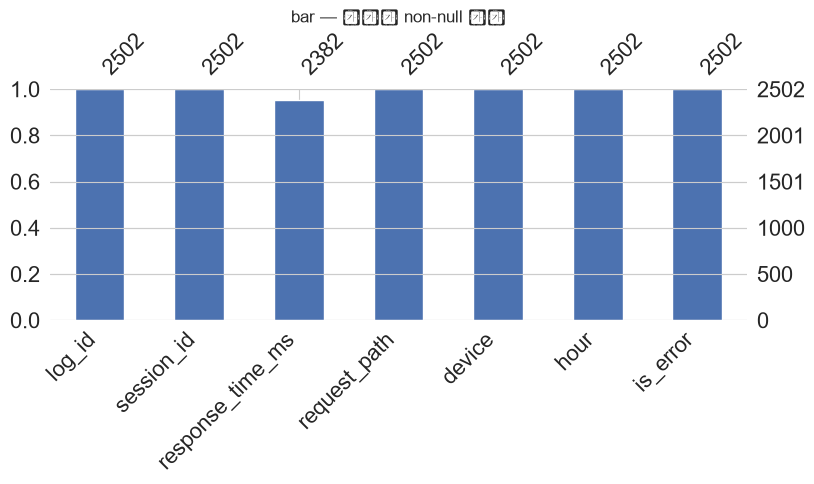


[질문 2] matrix — 원래 순서(정렬 전)


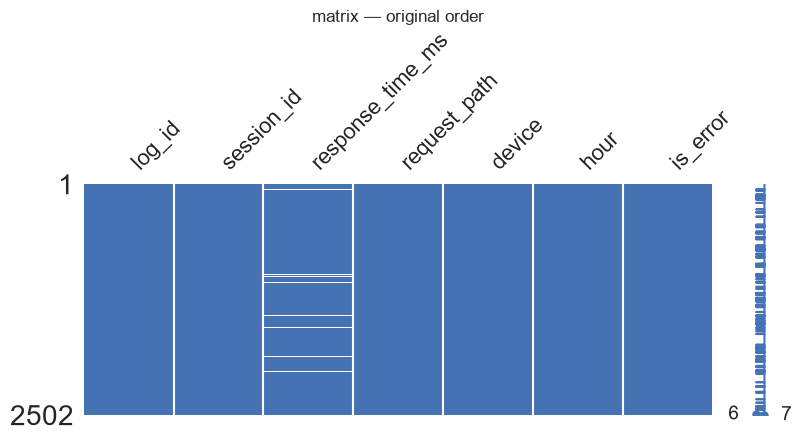


[질문 3-1] matrix — hour 기준 정렬 후 (시각적 신호)


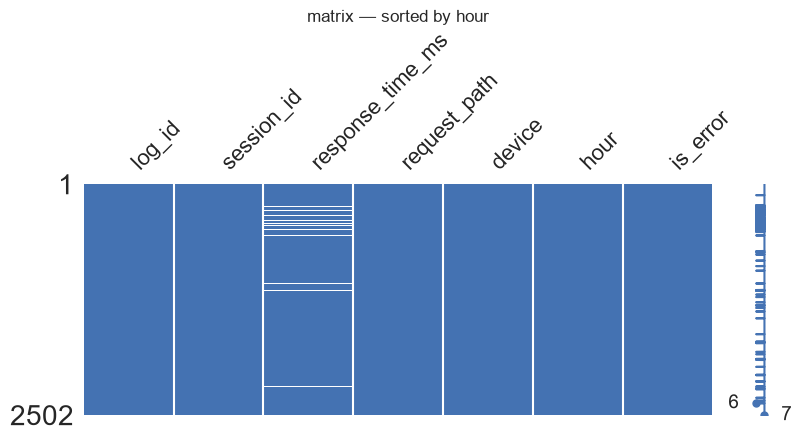


[질문 3-2] 결측 행들의 hour 값 분포 (그림 속 '뭉침'의 실체)
hour
1      1
2     30
3     34
4     16
5      1
6      1
7      2
8      2
9      1
10     2
11     4
12     4
13     2
15     1
16     3
17     2
18     3
19     3
20     2
21     3
22     3
Name: count, dtype: int64

시간대별 결측률(%) — 내림차순
 hour  missing_pct
    2         30.6
    3         27.9
    4         21.1
   12          4.4
   11          3.5
   18          3.0
   22          2.7
   16          2.7
   19          2.7
   21          2.6
   20          2.1
   17          2.1
    7          2.1
    8          2.0
   13          1.9
   10          1.8
   15          1.0
    6          1.0
    1          0.9
    5          0.9
    9          0.9
    0          0.0
   14          0.0
   23          0.0
전체 평균 결측률: 4.8%


In [9]:
# ─────────────────────────────────────────────
# 시나리오 1 — 결측 패턴 진단 (missingno + 근거 확인)
# 앞서 만든 logs_raw를 그대로 사용합니다.
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import missingno as msno

# ── 질문 1: response_time_ms의 결측 비율은? ──────────────────────
print("[질문 1] 컬럼별 결측 개수 · 비율(%)")
print(logs_raw.isnull().sum())
print((logs_raw.isnull().mean() * 100).round(2))

msno.bar(logs_raw, color="#4C72B0", figsize=(9, 3))
plt.title("bar — 컬럼별 non-null 비율")
plt.show()


# ── 질문 2: matrix에서 결측이 무작위인가, 몰려 있는가? ────────────
print("\n[질문 2] matrix — 원래 순서(정렬 전)")
msno.matrix(logs_raw, color=(0.27, 0.45, 0.70), figsize=(9, 3))
plt.title("matrix — original order")
plt.show()


# ── 질문 3-1: hour 순으로 정렬하면 패턴이 달라지는가? (그림으로 신호 포착) ──
# sort_values("hour")는 오름차순이므로 hour=0이 맨 위, hour=23이 맨 아래에 옵니다.
# 이 그림은 "어딘가에 결측이 뭉쳐 있다"는 신호만 줄 뿐,
# 그 위치가 정확히 몇 시인지는 아직 알려주지 않습니다.
print("\n[질문 3-1] matrix — hour 기준 정렬 후 (시각적 신호)")
sorted_by_hour = logs_raw.sort_values("hour").reset_index(drop=True)
msno.matrix(sorted_by_hour, color=(0.27, 0.45, 0.70), figsize=(9, 3))
plt.title("matrix — sorted by hour")
plt.show()


# ── 질문 3-2: 그 "몰림"이 실제로 몇 시인지 숫자로 확정 (근거 확인) ────
# matrix는 위치(행 순서)만 보여주므로, 결측인 행들을 직접 골라서
# 그 행들의 실제 hour 값이 무엇인지 확인해야 "새벽에 몰려 있다"는
# 문장을 근거 있게 쓸 수 있다.
missing_rows = sorted_by_hour[sorted_by_hour["response_time_ms"].isna()]

print("\n[질문 3-2] 결측 행들의 hour 값 분포 (그림 속 '뭉침'의 실체)")
print(missing_rows["hour"].value_counts().sort_index())

# 시간대별 결측률로도 같은 근거를 재확인 (개수 대신 비율 기준)
by_hour_missing = (
    logs_raw[logs_raw["hour"].between(0, 23)]
    .groupby("hour")["response_time_ms"]
    .apply(lambda s: s.isna().mean() * 100)
    .rename("missing_pct")
    .reset_index()
)
overall_missing = logs_raw["response_time_ms"].isna().mean() * 100

print("\n시간대별 결측률(%) — 내림차순")
print(by_hour_missing.sort_values("missing_pct", ascending=False).round(1).to_string(index=False))
print(f"전체 평균 결측률: {overall_missing:.1f}%")

# 평균보다 눈에 띄게(2배 이상) 높은 시간대만 추출해
# "심야에 집중됐다"는 표현을 쓸 수 있는지 최종 판단
spike_hours = sorted(
    by_hour_missing[by_hour_missing["missing_pct"] > overall_missing * 2]["hour"].tolist()
)

정제 전 shape: (2502, 7) -> 정제 후 shape: (2499, 7)
clean 결측 response_time_ms: 0
클리핑 상한(p99): 374.0ms


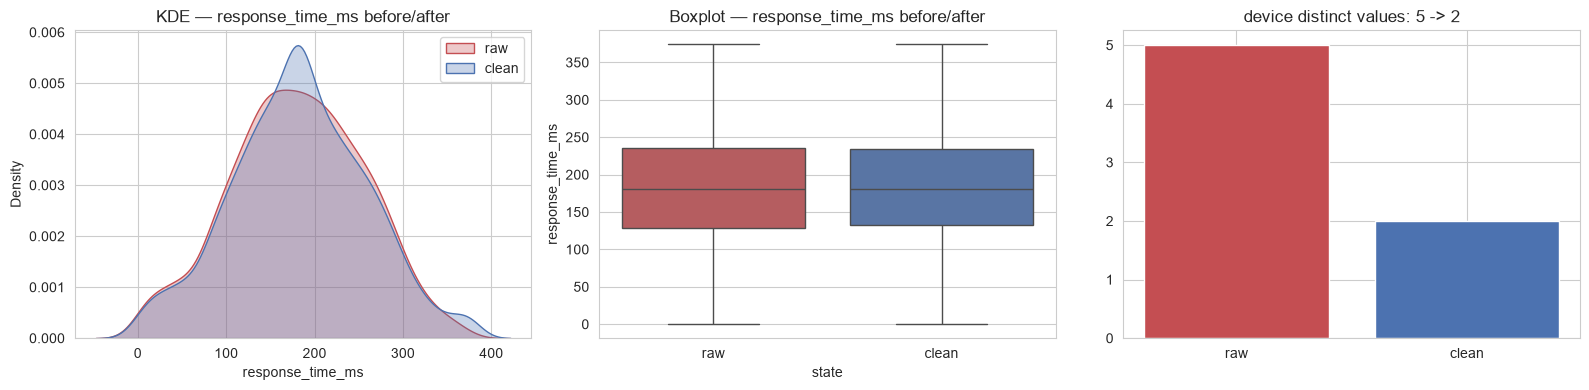


[검증 근거]
raw  response_time_ms: {'count': 2357.0, 'mean': 180.53, 'std': 75.3, 'min': 0.0, '25%': 129.0, '50%': 181.0, '75%': 235.0, 'max': 374.0}
clean response_time_ms: {'count': 2499.0, 'mean': 182.48, 'std': 75.6, 'min': 0.0, '25%': 132.0, '50%': 181.0, '75%': 234.0, 'max': 374.02}
device distinct: 5 -> 2


In [10]:
# ─────────────────────────────────────────────
# 시나리오 2 — 정제 + 검증 (전·후 분포 비교)
# 앞서 진단한 logs_raw를 그대로 이어받아 정제합니다.
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── 1. 중복 제거 ──────────────────────────────────────────────
logs_clean = logs_raw.drop_duplicates(subset="log_id").reset_index(drop=True)

# ── 2. device 표기 통일 (대소문자 혼재) ───────────────────────
device_map = {"mobile": "mobile", "Mobile": "mobile", "MOBILE": "mobile",
              "desktop": "desktop", "DESKTOP": "desktop"}
logs_clean["device"] = logs_clean["device"].map(device_map)

# ── 3. hour 이상치(99) 제거 ────────────────────────────────────
logs_clean = logs_clean[logs_clean["hour"].between(0, 23)].copy()

# ── 4. response_time_ms 결측 → request_path별 중앙값으로 대체 ──
medians = logs_clean.groupby("request_path")["response_time_ms"].median()
need = logs_clean["response_time_ms"].isna()
logs_clean.loc[need, "response_time_ms"] = logs_clean.loc[need, "request_path"].map(medians)

# ── 5. response_time_ms 극단치 → 99% 분위수로 클리핑 ───────────
cap = logs_clean["response_time_ms"].quantile(0.99)
logs_clean.loc[logs_clean["response_time_ms"] > cap, "response_time_ms"] = cap

print(f"정제 전 shape: {logs_raw.shape} -> 정제 후 shape: {logs_clean.shape}")
print(f"clean 결측 response_time_ms: {logs_clean['response_time_ms'].isna().sum()}")
print(f"클리핑 상한(p99): {cap:.1f}ms")


# ── 검증 — 전·후 분포 비교 3종 세트 ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (왼쪽) KDE 겹쳐 그리기 — raw는 결측 제거 + cap 이하만 필터링해서 공정하게 비교
raw_rt = logs_raw["response_time_ms"].dropna()
raw_rt = raw_rt[raw_rt <= cap]
sns.kdeplot(raw_rt, label="raw", color="#C44E52", fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(logs_clean["response_time_ms"], label="clean", color="#4C72B0", fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("KDE — response_time_ms before/after")
axes[0].legend()

# (가운데) Boxplot side-by-side — long-format으로 합쳐서 비교
long_rt = pd.concat([
    pd.DataFrame({"response_time_ms": raw_rt.values, "state": "raw"}),
    pd.DataFrame({"response_time_ms": logs_clean["response_time_ms"].values, "state": "clean"}),
])
sns.boxplot(data=long_rt, x="state", y="response_time_ms",
            order=["raw", "clean"], ax=axes[1], palette=["#C44E52", "#4C72B0"])
axes[1].set_title("Boxplot — response_time_ms before/after")

# (오른쪽) device 정제 검증 — 고윳값 개수 비교
raw_dev_n = logs_raw["device"].nunique()
cln_dev_n = logs_clean["device"].nunique()
axes[2].bar(["raw", "clean"], [raw_dev_n, cln_dev_n], color=["#C44E52", "#4C72B0"])
axes[2].set_title(f"device distinct values: {raw_dev_n} -> {cln_dev_n}")

plt.tight_layout()
plt.show()

# ── 읽는 법 그대로, 검증 결과를 숫자로도 확인 ──────────────────
print("\n[검증 근거]")
print("raw  response_time_ms:", raw_rt.describe().round(2).to_dict())
print("clean response_time_ms:", logs_clean["response_time_ms"].describe().round(2).to_dict())
print(f"device distinct: {raw_dev_n} -> {cln_dev_n}")

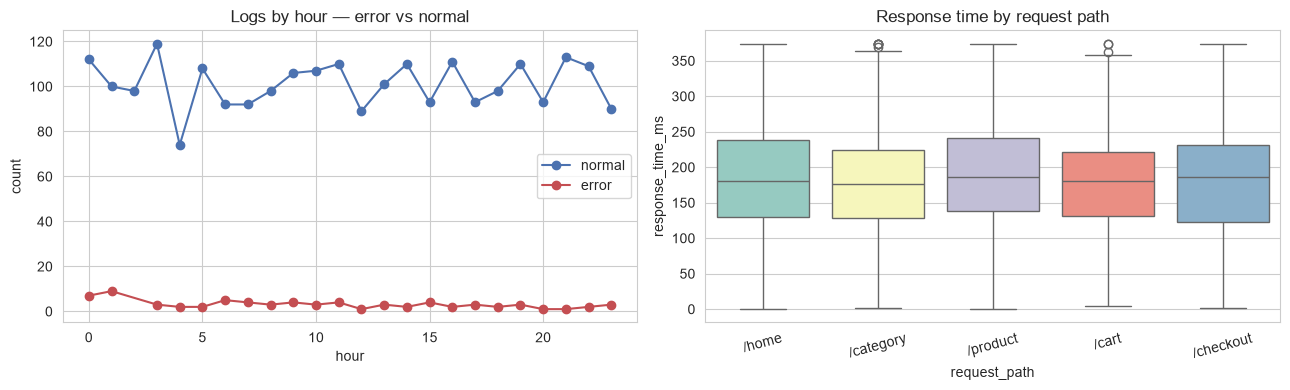

[근거 1] 시간대별 에러율(%) — 표본 수(n)도 함께 확인
 hour   n  err_rate
    1 109      8.26
    0 119      5.88
    6  97      5.15
    7  96      4.17
   15  97      4.12
    9 110      3.64
   11 114      3.51
   23  93      3.23
   17  96      3.12
    8 101      2.97
   13 104      2.88
   10 110      2.73
   19 113      2.65
    4  76      2.63
    3 122      2.46
   18 100      2.00
    5 110      1.82
   22 111      1.80
   14 112      1.79
   16 113      1.77
   12  90      1.11
   20  94      1.06
   21 114      0.88
    2  98      0.00
전체 평균 에러율: 2.92%
→ '심야(2~4시)'로 뭉뚱그리면 진짜 튀는 시간(예: 1시)이 가려질 수 있으니,
  시간 단위 표에서 실제로 튀는 hour가 몇 시인지 확인한 뒤에만 가설 문구를 쓸 것

[근거 2] 요청 경로별 응답 시간 통계 (평균·중앙값)
               mean  median  count
request_path                      
/product      187.7   186.0    620
/home         183.1   181.0    912
/cart         182.1   180.0    259
/checkout     178.6   186.0    207
/category     176.6   176.0    501
→ 박스플롯에서 눈에 띈 경로가 실제로 평균·중앙값도 높은지 여기서 재확인


In [11]:
# ─────────────────────────────────────────────
# 시나리오 3 — 정제 데이터에서 패턴 탐색
# 검증을 마친 logs_clean을 이어받아 새 질문을 발굴합니다.
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── (왼쪽) 시간대별 로그 수 — 정상 vs 에러 ─────────────────────
hour_err = logs_clean.groupby(["hour", "is_error"]).size().reset_index(name="n")
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    part = hour_err[hour_err["is_error"] == label]
    axes[0].plot(part["hour"], part["n"], marker="o",
                 label="normal" if label == 0 else "error", color=color)
axes[0].set_title("Logs by hour — error vs normal")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("count"); axes[0].legend()

# ── (오른쪽) 요청 경로별 응답 시간 분포 ─────────────────────────
sns.boxplot(data=logs_clean, x="request_path", y="response_time_ms",
            order=["/home", "/category", "/product", "/cart", "/checkout"],
            ax=axes[1], palette="Set3")
axes[1].set_title("Response time by request path")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


# ── 그림에서 본 인상을 숫자로 확인 (근거 없이 "심야 패턴"이라 단정하지 않기) ──
print("[근거 1] 시간대별 에러율(%) — 표본 수(n)도 함께 확인")
err_by_hour = (
    logs_clean.groupby("hour")["is_error"]
    .agg(n="size", err_rate=lambda s: s.mean() * 100)
    .reset_index()
)
overall_err = logs_clean["is_error"].mean() * 100
print(err_by_hour.sort_values("err_rate", ascending=False).round(2).to_string(index=False))
print(f"전체 평균 에러율: {overall_err:.2f}%")
print("→ '심야(2~4시)'로 뭉뚱그리면 진짜 튀는 시간(예: 1시)이 가려질 수 있으니,")
print("  시간 단위 표에서 실제로 튀는 hour가 몇 시인지 확인한 뒤에만 가설 문구를 쓸 것")

print("\n[근거 2] 요청 경로별 응답 시간 통계 (평균·중앙값)")
path_stats = logs_clean.groupby("request_path")["response_time_ms"].agg(["mean", "median", "count"])
print(path_stats.sort_values("mean", ascending=False).round(1))
print("→ 박스플롯에서 눈에 띈 경로가 실제로 평균·중앙값도 높은지 여기서 재확인")

# 모두마켓 웹 접속 로그 — EDA & 시각화 보고서

## 1. 데이터 개요
- 행/열: **2,502행, 7열** (정제 전 기준)
- 주요 컬럼: log_id, session_id, response_time_ms, request_path, device, hour, is_error

## 2. 결측 진단 (missingno)
- `response_time_ms` 결측 비율: **4.8%**
- 결측 패턴: hour 기준 정렬 후 matrix에서 위쪽(새벽대)에 결측이 뭉쳐 보였고, 실제 시간대별 결측률을 확인한 결과 **2시 30.6% · 3시 27.9% · 4시 21.1%**로 압도적으로 높음 (다음 순위인 12시는 4.4%로 확 떨어짐)
- 의심 가설: 결측이 특정 소수 시간대(2~4시)에만 극단적으로 집중된 걸로 봐서, **심야 시간대 응답 측정 모듈 점검 작업으로 측정값이 누락**됐을 가능성. 다만 이 시간대 외에도 소량의 결측이 흩어져 있어(예: 0시 등), 원인이 100% 단일하지는 않을 수 있음.

## 3. 정제와 검증 (전·후 분포 비교)
- 적용한 정제: 중복 제거(2건) / device 표기 통일(5→2종) / hour 이상치(99, 1건) 제거 / response_time_ms 결측을 request_path별 중앙값으로 대체 / 극단치를 99% 분위수 기준으로 클리핑
- 정제 전후 shape: **2,502행 → 2,499행**
- KDE 비교 결과: **본질이 유지됨.** raw(결측 제거·cap 이하 기준) 평균 180.53ms·표준편차 75.30, clean 평균 182.48ms·표준편차 75.60으로 거의 일치 — 경로별 중앙값 대체가 전체 분포의 중심·퍼짐을 왜곡하지 않았음
- device distinct: 5 → **2** (정상)

## 4. 탐색에서 도출한 새 질문
- **"에러는 심야가 아니라 오전 1시·0시에 집중된다"** — 시간 단위로 에러율을 뽑아보면 1시가 8.26%(표본 109건), 0시가 5.88%(119건)로 전체 평균(2.92%)보다 뚜렷하게 높음. 반면 2~4시(흔히 "심야"로 묶는 구간)는 오히려 평균 이하이거나 낮은 편이라, "심야=에러 다발"이라는 직관적 가정은 이 데이터에서 지지되지 않음. → **왜 0~1시에만 에러가 튀는지**가 다음 질문.
- **"`/checkout`이 가장 느리다"는 가정도 지지되지 않음** — 평균 응답시간 기준으로는 `/product`(187.7ms)가 가장 높고 `/checkout`(178.6ms)은 중간 이하. 다만 `/checkout`의 중앙값(186.0ms)은 평균보다 높아, 일부 소수 건이 응답시간을 끌어올리는 비대칭 분포일 가능성 → `/checkout` 응답시간의 분포 모양(왜도)을 별도로 봐야 할 필요가 있음.

## 5. 전달용 차트 1개
`px.bar(hour × is_error, barmode="group")` — 시간대별 정상/에러 로그 건수를 그룹 막대로 표현.
**한 줄 메시지: "에러는 심야(2~4시)가 아니라 자정 직후(0~1시)에 몰려 있으며, 표본 수(n≈110~120건)를 감안해도 평균의 2배 이상 튀는 구간이다."**

## 6. 다음 분석 제안
- **0~1시 에러 집중 원인 추적**: 배치 작업, 캐시 워밍업, 야간 배포 등 자정 직후에 실행되는 시스템 이벤트와의 연관성 확인
- **`/product`·`/checkout` 응답시간 분포 재검토**: 평균·중앙값이 서로 다른 순위를 보이는 만큼, 두 경로의 분포 모양(왜도·이상치 비율)을 별도 히스토그램/박스플롯으로 비교
- **디바이스별 성능 비교**: 오늘은 표기 통일만 했으므로, mobile vs desktop 간 response_time_ms 차이를 다음 단계로 탐색